In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [8]:
print(trades.head())
print(trades.info())
print(trades.describe())

print(sentiment.head())
print(sentiment.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [9]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [10]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
trades = trades.dropna()

In [12]:
print(trades.duplicated().sum())

0


In [13]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

Plots

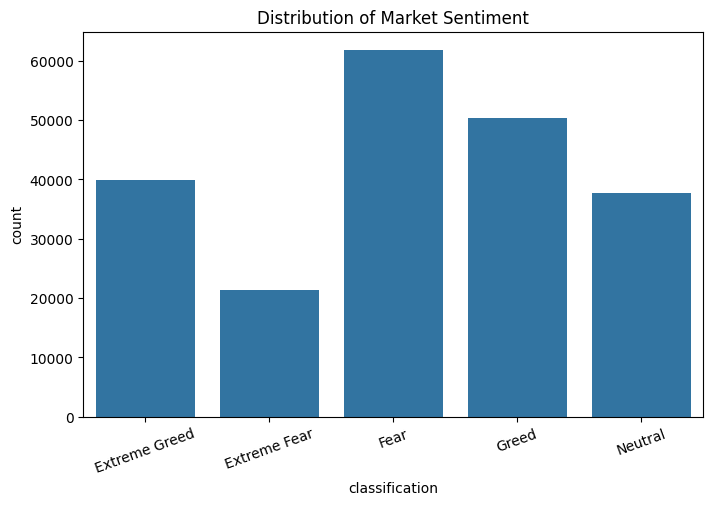

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=merged)
plt.title('Distribution of Market Sentiment')
plt.xticks(rotation=20)
plt.show()

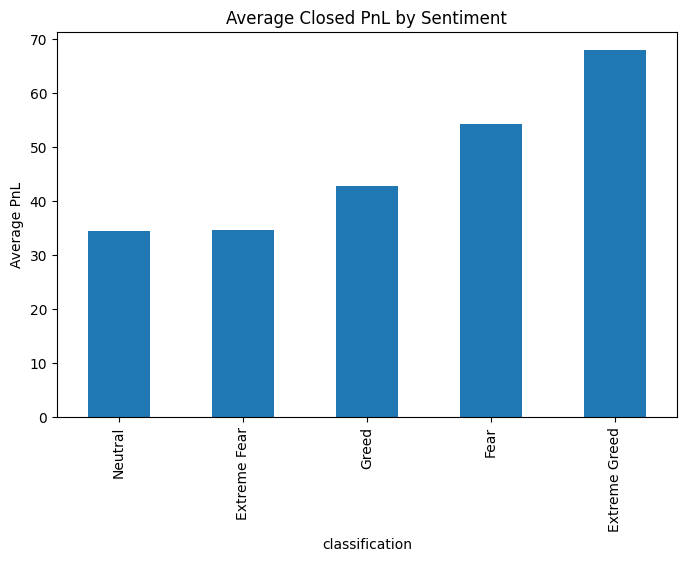

In [15]:
profit_by_sentiment = merged.groupby('classification')['Closed PnL'].mean().sort_values()

plt.figure(figsize=(8,5))
profit_by_sentiment.plot(kind='bar')
plt.title('Average Closed PnL by Sentiment')
plt.ylabel('Average PnL')
plt.show()

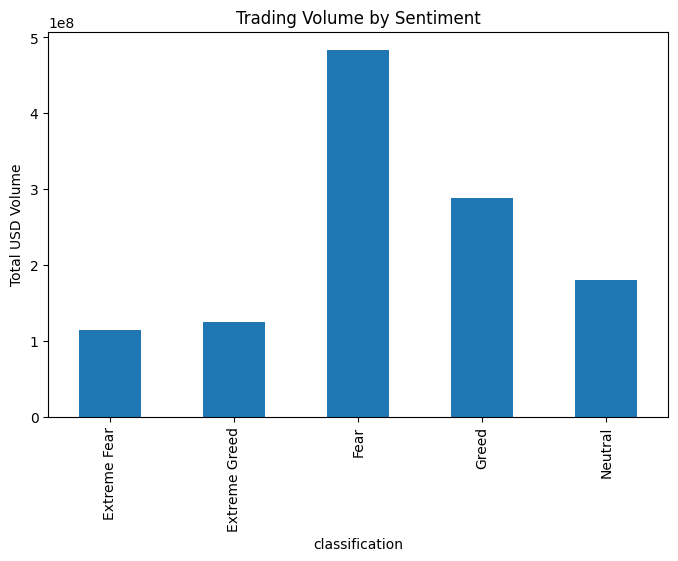

In [16]:
volume_by_sentiment = merged.groupby('classification')['Size USD'].sum()

plt.figure(figsize=(8,5))
volume_by_sentiment.plot(kind='bar')
plt.title('Trading Volume by Sentiment')
plt.ylabel('Total USD Volume')
plt.show()

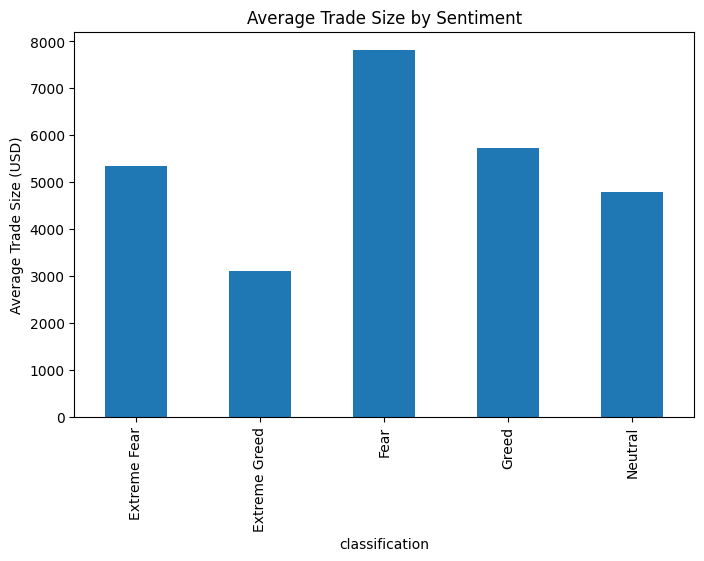

In [17]:
risk_analysis = merged.groupby('classification')['Size USD'].mean()

plt.figure(figsize=(8,5))
risk_analysis.plot(kind='bar')
plt.title('Average Trade Size by Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.show()

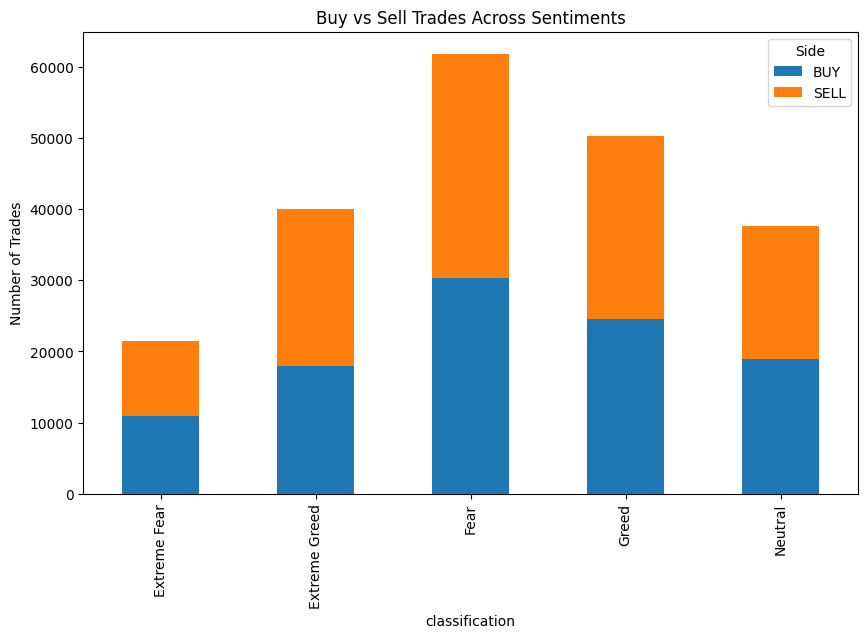

In [18]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

side_analysis.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Buy vs Sell Trades Across Sentiments')
plt.ylabel('Number of Trades')
plt.show()

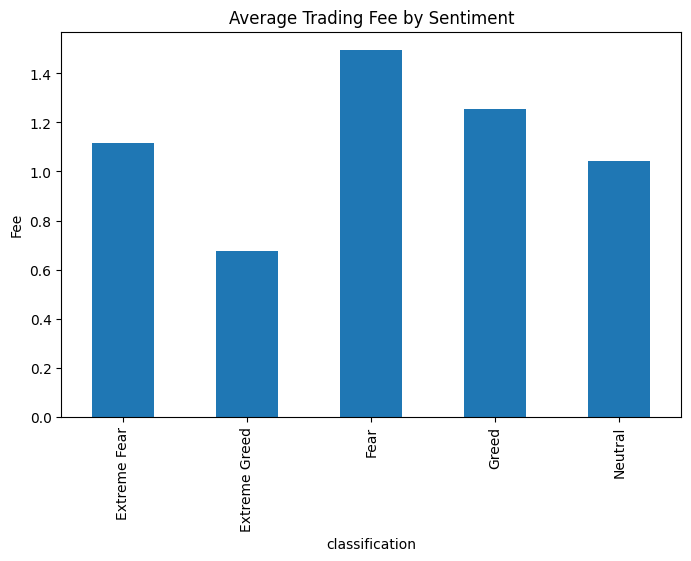

In [19]:
fee_analysis = merged.groupby('classification')['Fee'].mean()

plt.figure(figsize=(8,5))
fee_analysis.plot(kind='bar')
plt.title('Average Trading Fee by Sentiment')
plt.ylabel('Fee')
plt.show()

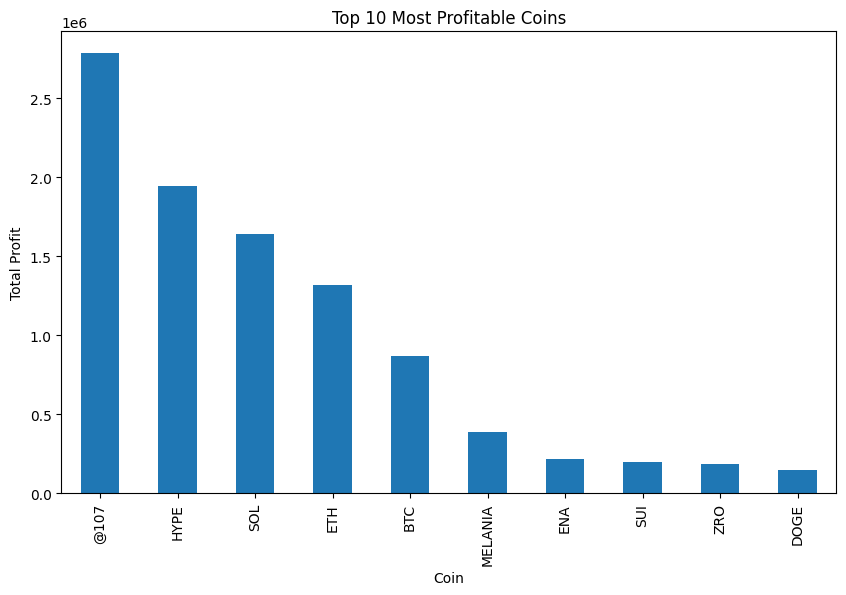

In [20]:
coin_profit = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
coin_profit.plot(kind='bar')
plt.title('Top 10 Most Profitable Coins')
plt.ylabel('Total Profit')
plt.show()

In [21]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [22]:
trader_features = merged.groupby('Account').agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Fee': 'mean'
})

In [23]:
scaler = StandardScaler()
scaled = scaler.fit_transform(trader_features)

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['Cluster'] = kmeans.fit_predict(scaled)

print(trader_features.head())

                                              Closed PnL      Size USD  \
Account                                                                  
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  16159.576734   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04   1653.226327   
0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04   8893.000898   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05    507.626933   
0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05   3138.894782   

                                                 Fee  Cluster  
Account                                                        
0x083384f897ee0f19899168e3b1bec365f52a9012  1.939579        0  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.374978        1  
0x271b280974205ca63b716753467d5a371de622ab  2.436593        1  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.166657        1  
0x2c229d22b100a7beb69122eed721cee9b24011dd  0.959616        1  


In [25]:
model_df = merged.copy()

model_df['Side'] = model_df['Side'].astype('category').cat.codes
model_df['classification'] = model_df['classification'].astype('category').cat.codes

In [26]:
X = model_df[[
    'Execution Price',
    'Size USD',
    'Fee',
    'Side',
    'classification'
]]

y = model_df['Closed PnL']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print('RMSE:', rmse)

RMSE: 1169.1127821941552
